# Chronic Depression Data Analysis
## Exploratory Data Analysis (EDA) & Data Cleaning

This notebook performs data cleaning, exploratory data analysis, feature engineering, and produces insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_theme()

df=pd.read_csv('depression_data.csv')
df.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


## Dataset Shape

In [2]:
print('Shape:',df.shape)
df.info()

Shape: (413768, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Name                          413768 non-null  object 
 1   Age                           413768 non-null  int64  
 2   Marital Status                413768 non-null  object 
 3   Education Level               413768 non-null  object 
 4   Number of Children            413768 non-null  int64  
 5   Smoking Status                413768 non-null  object 
 6   Physical Activity Level       413768 non-null  object 
 7   Employment Status             413768 non-null  object 
 8   Income                        413768 non-null  float64
 9   Alcohol Consumption           413768 non-null  object 
 10  Dietary Habits                413768 non-null  object 
 11  Sleep Patterns                413768 non-null  object 
 12  History of Mental Illnes

**Insight:** Understand dataset dimensions and data types before cleaning.

## Missing Values

In [3]:
df.isnull().sum()

Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
Chronic Medical Conditions      0
dtype: int64

**Insight:** If all values are zero, the dataset has no missing values.

## Duplicate Records

In [4]:
print('Duplicates:',df.duplicated().sum())
df=df.drop_duplicates()

Duplicates: 0


## Summary Statistics

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,413768,196851,Michael Smith,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,413768.0,NaN,NaN,NaN,49.000713,18.158759,18.0,33.0,49.0,65.0,80.0
Marital Status,413768,4,Married,240444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,413768,5,Bachelor's Degree,124329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Children,413768.0,NaN,NaN,NaN,1.298972,1.237054,0.0,0.0,1.0,2.0,4.0
Smoking Status,413768,3,Non-smoker,247416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Physical Activity Level,413768,3,Sedentary,176850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment Status,413768,2,Employed,265659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,413768.0,NaN,NaN,NaN,50661.707971,40624.100565,0.41,21001.03,37520.135,76616.3,209995.22
Alcohol Consumption,413768,3,Moderate,173440,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Numerical Distributions

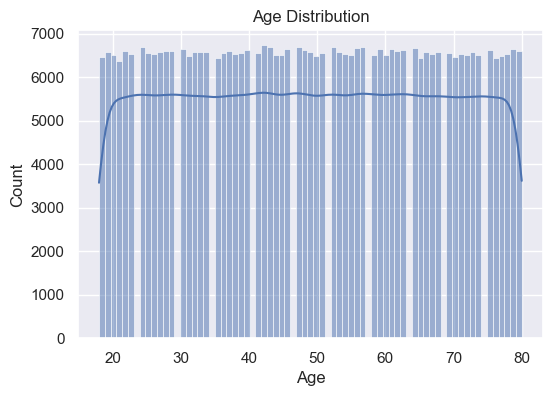

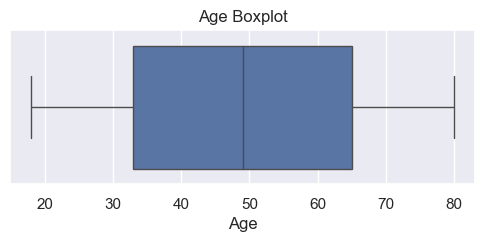

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'],kde=True)
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(6,2))
sns.boxplot(x=df['Age'])
plt.title('Age Boxplot')
plt.show()

**Insight:** Examine distribution and possible outliers for **Age**.

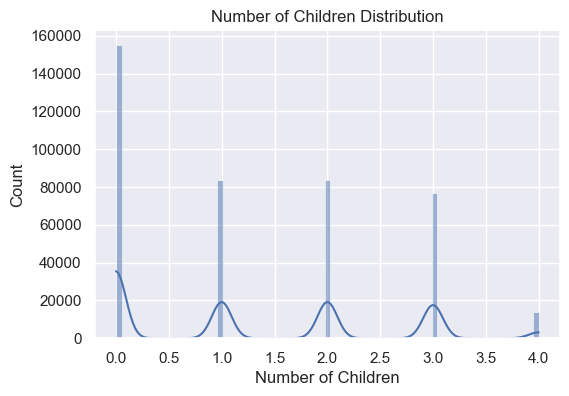

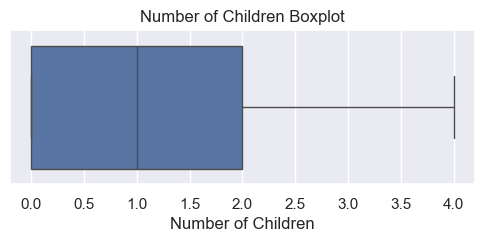

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Number of Children'],kde=True)
plt.title('Number of Children Distribution')
plt.show()

plt.figure(figsize=(6,2))
sns.boxplot(x=df['Number of Children'])
plt.title('Number of Children Boxplot')
plt.show()

**Insight:** Examine distribution and possible outliers for **Number of Children**.

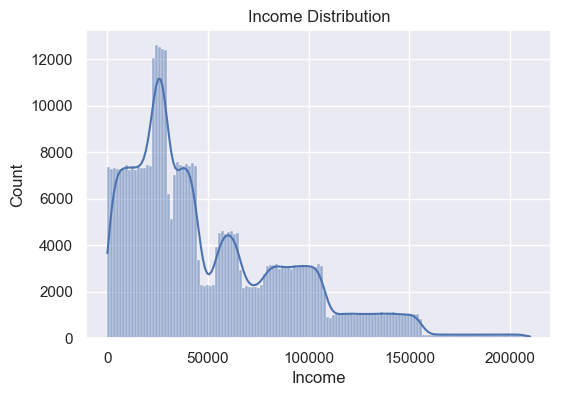

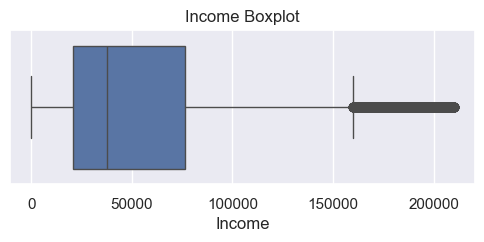

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Income'],kde=True)
plt.title('Income Distribution')
plt.show()

plt.figure(figsize=(6,2))
sns.boxplot(x=df['Income'])
plt.title('Income Boxplot')
plt.show()

**Insight:** Examine distribution and possible outliers for **Income**.

## Categorical Variable Analysis

**Insight:** Observe class balance in **Name**.

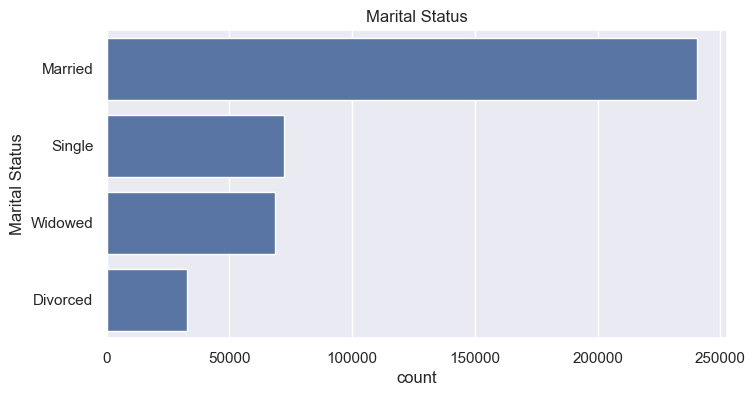

Marital Status
Married     58.110825
Single      17.427641
Widowed     16.551546
Divorced     7.909988
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(8,4))
order=df['Marital Status'].value_counts().index
sns.countplot(y=df['Marital Status'],order=order)
plt.title('Marital Status')
plt.show()
print(df['Marital Status'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Marital Status**.

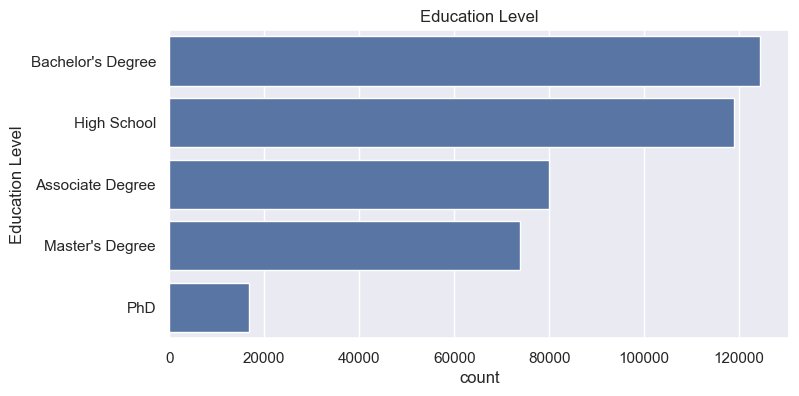

Education Level
Bachelor's Degree    30.047998
High School          28.742435
Associate Degree     19.334265
Master's Degree      17.828348
PhD                   4.046954
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(8,4))
order=df['Education Level'].value_counts().index
sns.countplot(y=df['Education Level'],order=order)
plt.title('Education Level')
plt.show()
print(df['Education Level'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Education Level**.

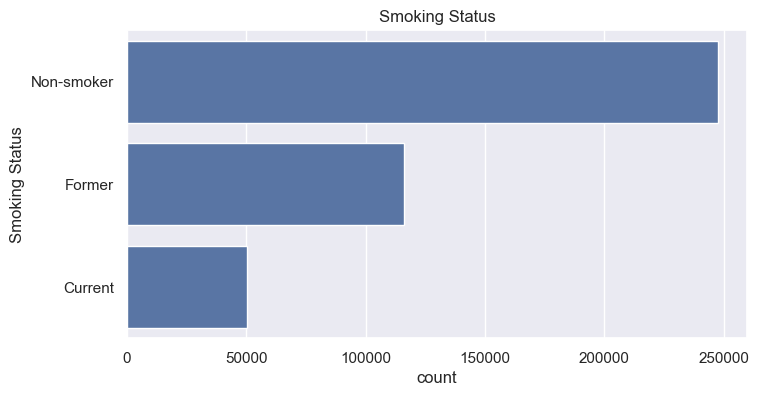

Smoking Status
Non-smoker    59.795828
Former        28.079503
Current       12.124669
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(8,4))
order=df['Smoking Status'].value_counts().index
sns.countplot(y=df['Smoking Status'],order=order)
plt.title('Smoking Status')
plt.show()
print(df['Smoking Status'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Smoking Status**.

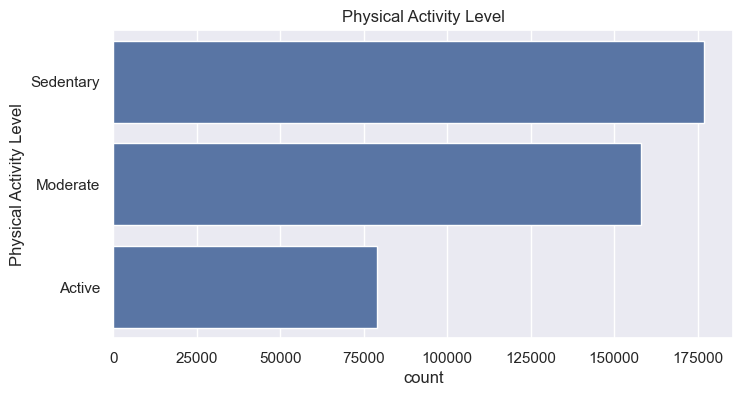

Physical Activity Level
Sedentary    42.741343
Moderate     38.188792
Active       19.069865
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(8,4))
order=df['Physical Activity Level'].value_counts().index
sns.countplot(y=df['Physical Activity Level'],order=order)
plt.title('Physical Activity Level')
plt.show()
print(df['Physical Activity Level'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Physical Activity Level**.

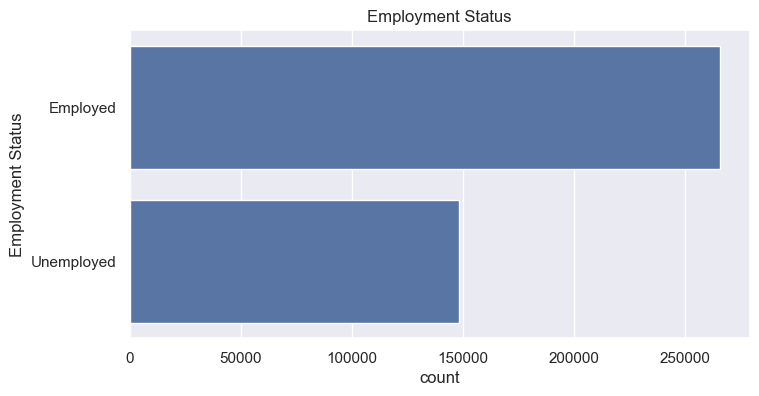

Employment Status
Employed      64.20482
Unemployed    35.79518
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(8,4))
order=df['Employment Status'].value_counts().index
sns.countplot(y=df['Employment Status'],order=order)
plt.title('Employment Status')
plt.show()
print(df['Employment Status'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Employment Status**.

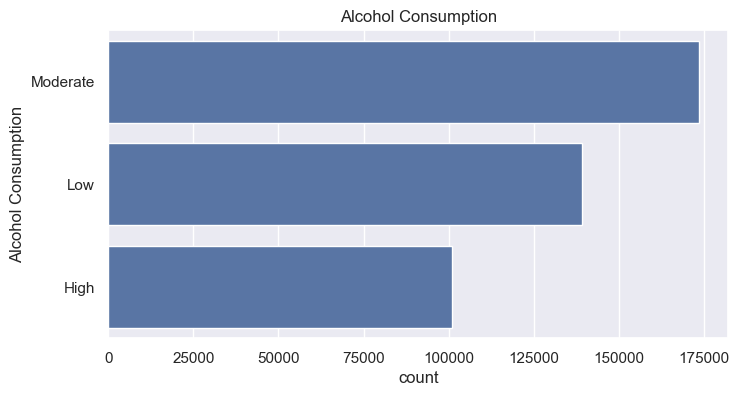

Alcohol Consumption
Moderate    41.917210
Low         33.654125
High        24.428665
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(8,4))
order=df['Alcohol Consumption'].value_counts().index
sns.countplot(y=df['Alcohol Consumption'],order=order)
plt.title('Alcohol Consumption')
plt.show()
print(df['Alcohol Consumption'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Alcohol Consumption**.

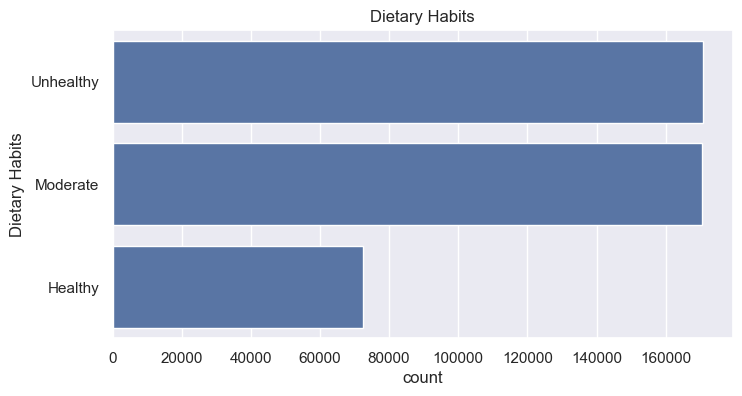

Dietary Habits
Unhealthy    41.283280
Moderate     41.193616
Healthy      17.523105
Name: proportion, dtype: float64


In [15]:
plt.figure(figsize=(8,4))
order=df['Dietary Habits'].value_counts().index
sns.countplot(y=df['Dietary Habits'],order=order)
plt.title('Dietary Habits')
plt.show()
print(df['Dietary Habits'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Dietary Habits**.

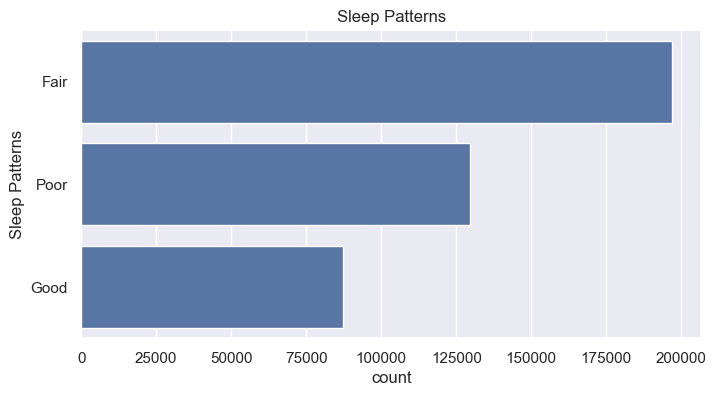

Sleep Patterns
Fair    47.560227
Poor    31.317550
Good    21.122223
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(8,4))
order=df['Sleep Patterns'].value_counts().index
sns.countplot(y=df['Sleep Patterns'],order=order)
plt.title('Sleep Patterns')
plt.show()
print(df['Sleep Patterns'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Sleep Patterns**.

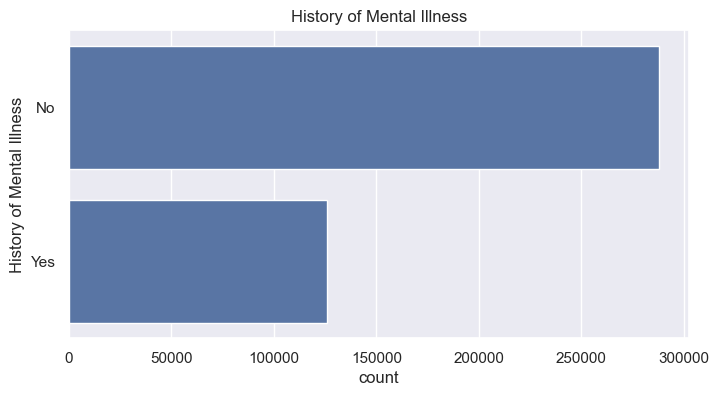

History of Mental Illness
No     69.590447
Yes    30.409553
Name: proportion, dtype: float64


In [17]:
plt.figure(figsize=(8,4))
order=df['History of Mental Illness'].value_counts().index
sns.countplot(y=df['History of Mental Illness'],order=order)
plt.title('History of Mental Illness')
plt.show()
print(df['History of Mental Illness'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **History of Mental Illness**.

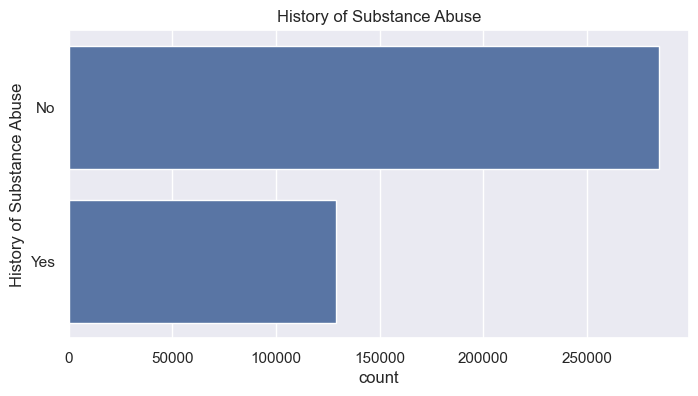

History of Substance Abuse
No     68.850177
Yes    31.149823
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(8,4))
order=df['History of Substance Abuse'].value_counts().index
sns.countplot(y=df['History of Substance Abuse'],order=order)
plt.title('History of Substance Abuse')
plt.show()
print(df['History of Substance Abuse'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **History of Substance Abuse**.

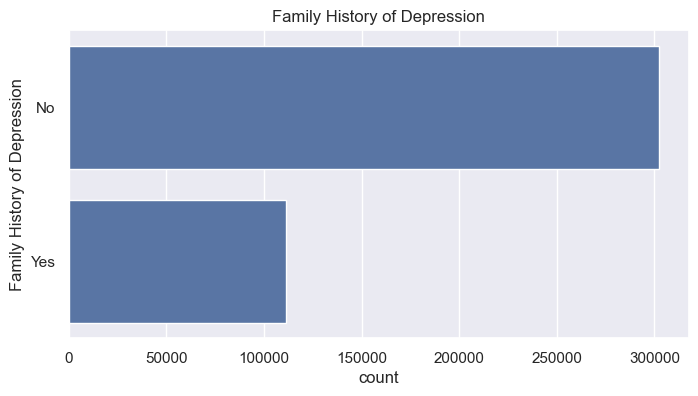

Family History of Depression
No     73.112227
Yes    26.887773
Name: proportion, dtype: float64


In [19]:
plt.figure(figsize=(8,4))
order=df['Family History of Depression'].value_counts().index
sns.countplot(y=df['Family History of Depression'],order=order)
plt.title('Family History of Depression')
plt.show()
print(df['Family History of Depression'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Family History of Depression**.

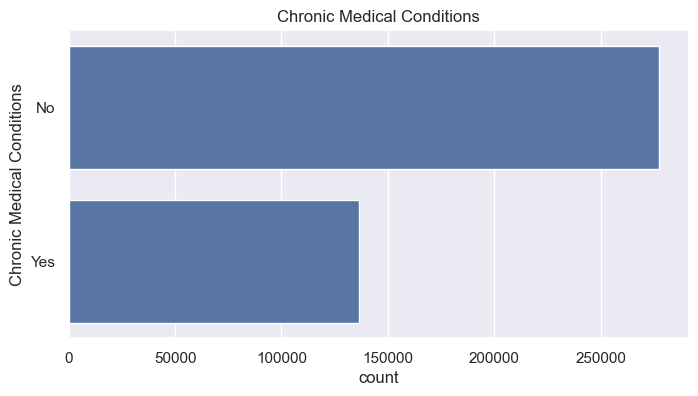

Chronic Medical Conditions
No     67.081311
Yes    32.918689
Name: proportion, dtype: float64


In [20]:
plt.figure(figsize=(8,4))
order=df['Chronic Medical Conditions'].value_counts().index
sns.countplot(y=df['Chronic Medical Conditions'],order=order)
plt.title('Chronic Medical Conditions')
plt.show()
print(df['Chronic Medical Conditions'].value_counts(normalize=True)*100)

**Insight:** Observe class balance in **Chronic Medical Conditions**.

## Correlation Analysis

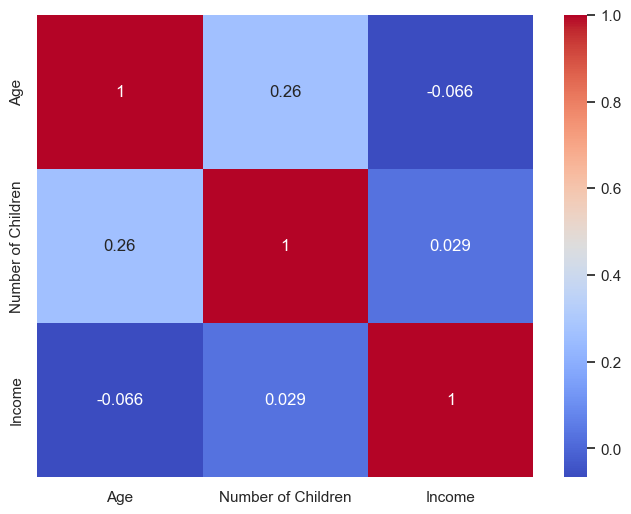

In [21]:
corr=df.select_dtypes(include='number').corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

**Insight:** Identify linear relationships among numerical variables.

## Feature Engineering

In [22]:
def lifestyle(row):
    risk=0
    if 'Smoking Status' in df.columns:
        if str(row['Smoking Status']).lower().startswith('current'):
            risk+=1
    if 'Alcohol Consumption' in df.columns:
        if str(row['Alcohol Consumption']).lower() in ['high','frequent']:
            risk+=1
    if 'Physical Activity Level' in df.columns:
        if str(row['Physical Activity Level']).lower()=='low':
            risk+=1
    return 'High' if risk>=2 else 'Moderate' if risk==1 else 'Low'

if set(['Smoking Status','Alcohol Consumption','Physical Activity Level']).issubset(df.columns):
    df['Lifestyle Risk']=df.apply(lifestyle,axis=1)
    print(df['Lifestyle Risk'].value_counts())


Lifestyle Risk
Low         282553
Moderate    111184
High         20031
Name: count, dtype: int64


## Business Questions

### Average income by marital status

In [23]:
df.groupby('Marital Status')['Income'].mean().sort_values(ascending=False)

Marital Status
Divorced    54761.356733
Married     51897.319120
Single      48615.993046
Widowed     46518.374568
Name: Income, dtype: float64

**Insight:** Interpret the table and compare the categories with the highest counts or averages.

### Average income by employment status

In [24]:
df.groupby('Employment Status')['Income'].mean()

Employment Status
Employed      70526.047302
Unemployed    15031.594189
Name: Income, dtype: float64

**Insight:** Interpret the table and compare the categories with the highest counts or averages.

### Smoking vs Physical Activity

In [25]:
pd.crosstab(df['Smoking Status'],df['Physical Activity Level'])

Physical Activity Level,Active,Moderate,Sedentary
Smoking Status,,,
Current,17280,17674,15214
Former,19460,45096,51628
Non-smoker,42165,95243,110008


**Insight:** Interpret the table and compare the categories with the highest counts or averages.

### Diet vs Chronic Condition

In [26]:
pd.crosstab(df['Dietary Habits'],df['Chronic Medical Conditions'])

Chronic Medical Conditions,No,Yes
Dietary Habits,,
Healthy,47424,25081
Moderate,114717,55729
Unhealthy,115420,55397


**Insight:** Interpret the table and compare the categories with the highest counts or averages.

### Mental Illness vs Substance Abuse

In [27]:
pd.crosstab(df['History of Mental Illness'],df['History of Substance Abuse'])

History of Substance Abuse,No,Yes
History of Mental Illness,,
No,198402,89541
Yes,86478,39347


**Insight:** Interpret the table and compare the categories with the highest counts or averages.

# Final Conclusions

- Dataset quality checked through missing value, duplicate, datatype and outlier analysis.
- Demographic, medical and lifestyle variables were explored individually.
- Correlation among numerical variables was examined.
- Lifestyle Risk feature was engineered.
- SQL analysis and Power BI dashboard complement this notebook by providing interactive reporting.
